# Machine Learning Lab Sheet 02

**Title:** Data Preprocessing Pipeline on WHO Life Expectancy Dataset  
**Name:** Lepmuhang Sherma  
**Roll No.:** 023-332

---

## 1. Objective
* To perform end-to-end data preprocessing steps including sanity checking, Exploratory Data Analysis (EDA), missing value imputation, outlier capping, normalization, and categorical encoding.
* To visualize univariate and bivariate distributions (histograms, box plots, scatter plots, and correlation heatmaps) for statistical interpretation.
* To transform raw real-world data into a clean, normalized numeric matrix ready for Machine Learning algorithms.

---

## 2. Theoretical Background

### 2.1 Sanity Checking & EDA
A sanity check verifies dataset integrity, missing value proportions, duplicate entries, and string noise before analysis. EDA utilizes visualizations to reveal skewed features, variance, and feature relationships with the target variable (`Life expectancy`).

### 2.2 Missing Value Imputation Methods
* **Simple Imputer:** Replaces missing numerical values using baseline measures like median or mean.
* **KNN Imputer:** Predicts missing values based on $k$-Nearest Neighbors in the feature space, preserving multivariate patterns:
$$d(x_i, x_j) = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$

### 2.3 Outlier Handling (IQR Capping)
Extreme outliers skew statistical models. The Interquartile Range (IQR) technique caps values beyond upper and lower boundaries:
$$\text{IQR} = Q3 - Q1, \quad \text{Lower Limit} = Q1 - 1.5 \times \text{IQR}, \quad \text{Upper Limit} = Q3 + 1.5 \times \text{IQR}$$

### 2.4 Normalization & Encoding
* **Min-Max Scaling:** Maps all numerical attributes to the interval $[0, 1]$:
$$X_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
* **One-Hot Encoding:** Converts string categories (`Country`, `Status`) into dummy binary indicators ($0$ or $1$) dropping the first category to avoid multicollinearity.

In [ ]:
# =========================================
# STEP 1: Import Necessary Libraries
# =========================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import kagglehub

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [ ]:
# =========================================
# STEP 2: Read Dataset directly from Kaggle
# =========================================
print("Downloading WHO Life Expectancy Dataset from Kaggle...")
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

csv_file = os.path.join(path, "Life Expectancy Data.csv")
df = pd.read_csv(csv_file)

# Strip leading/trailing whitespaces from column headers
df.columns = df.columns.str.strip()

print("\n--- Initial Dataset Head ---")
display(df.head())


Using Colab cache for faster access to the 'life-expectancy-who' dataset.

--- Initial Dataset Head ---


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
# =========================================
# STEP 3: Sanity Check of Data
# =========================================
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset Information ---")
df.info()

# Sanity Check Example: Nepal Data
print("\n--- Sanity Check: Displaying Data for Nepal ---")
nepal_data = df[df['Country'] == 'Nepal']
display(nepal_data.head())
print(f"Average Life Expectancy for Nepal: {nepal_data['Life expectancy'].mean():.2f} years")
# Check Missing Values and Percentage
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / df.shape[0]) * 100
})
print("\n--- Missing Values & Percentage ---")
print(missing_df[missing_df['Missing_Count'] > 0])

# Copy DataFrame for processing
dfc = df.copy()

print(f"\nDuplicate Records Count: {dfc.duplicated().sum()}")

# Garbage values check in object columns
print("\n--- Checking Value Counts for Categorical Features ---")
for col in dfc.select_dtypes(include="object").columns:
    print(dfc[col].value_counts())
    print("=" * 30)



--- Dataset Shape ---
(2938, 22)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths  

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1813,Nepal,2015,Developing,69.2,165.0,17,NaN,0.000000,91.0,1599,...,9.0,NaN,91.0,0.1,743.765349,28656282.0,15.7,16.1,0.555,12.2
1814,Nepal,2014,Developing,69.6,158.0,18,0.01,8.523486,92.0,1279,...,92.0,5.80,92.0,0.1,76.238698,28323241.0,15.9,16.3,0.551,12.4
1815,Nepal,2013,Developing,69.3,162.0,19,0.27,80.155051,92.0,1861,...,92.0,5.69,92.0,0.1,688.617279,2798531.0,16.1,16.5,0.545,12.3
1816,Nepal,2012,Developing,68.9,167.0,20,0.26,80.587884,9.0,3362,...,9.0,5.89,9.0,0.2,681.792587,27649925.0,16.3,16.7,0.538,12.3
1817,Nepal,2011,Developing,68.4,172.0,22,0.27,112.122903,92.0,2359,...,92.0,6.73,92.0,0.2,692.116684,27327147.0,16.5,16.9,0.529,12.0


Average Life Expectancy for Nepal: 66.48 years

--- Missing Values & Percentage ---
                                 Missing_Count  Percentage
Life expectancy                             10    0.340368
Adult Mortality                             10    0.340368
Alcohol                                    194    6.603131
Hepatitis B                                553   18.822328
BMI                                         34    1.157250
Polio                                       19    0.646698
Total expenditure                          226    7.692308
Diphtheria                                  19    0.646698
GDP                                        448   15.248468
Population                                 652   22.191967
thinness  1-19 years                        34    1.157250
thinness 5-9 years                          34    1.157250
Income composition of resources            167    5.684139
Schooling                                  163    5.547992

Duplicate Records Count: 0

--


--- Statistical Description ---


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


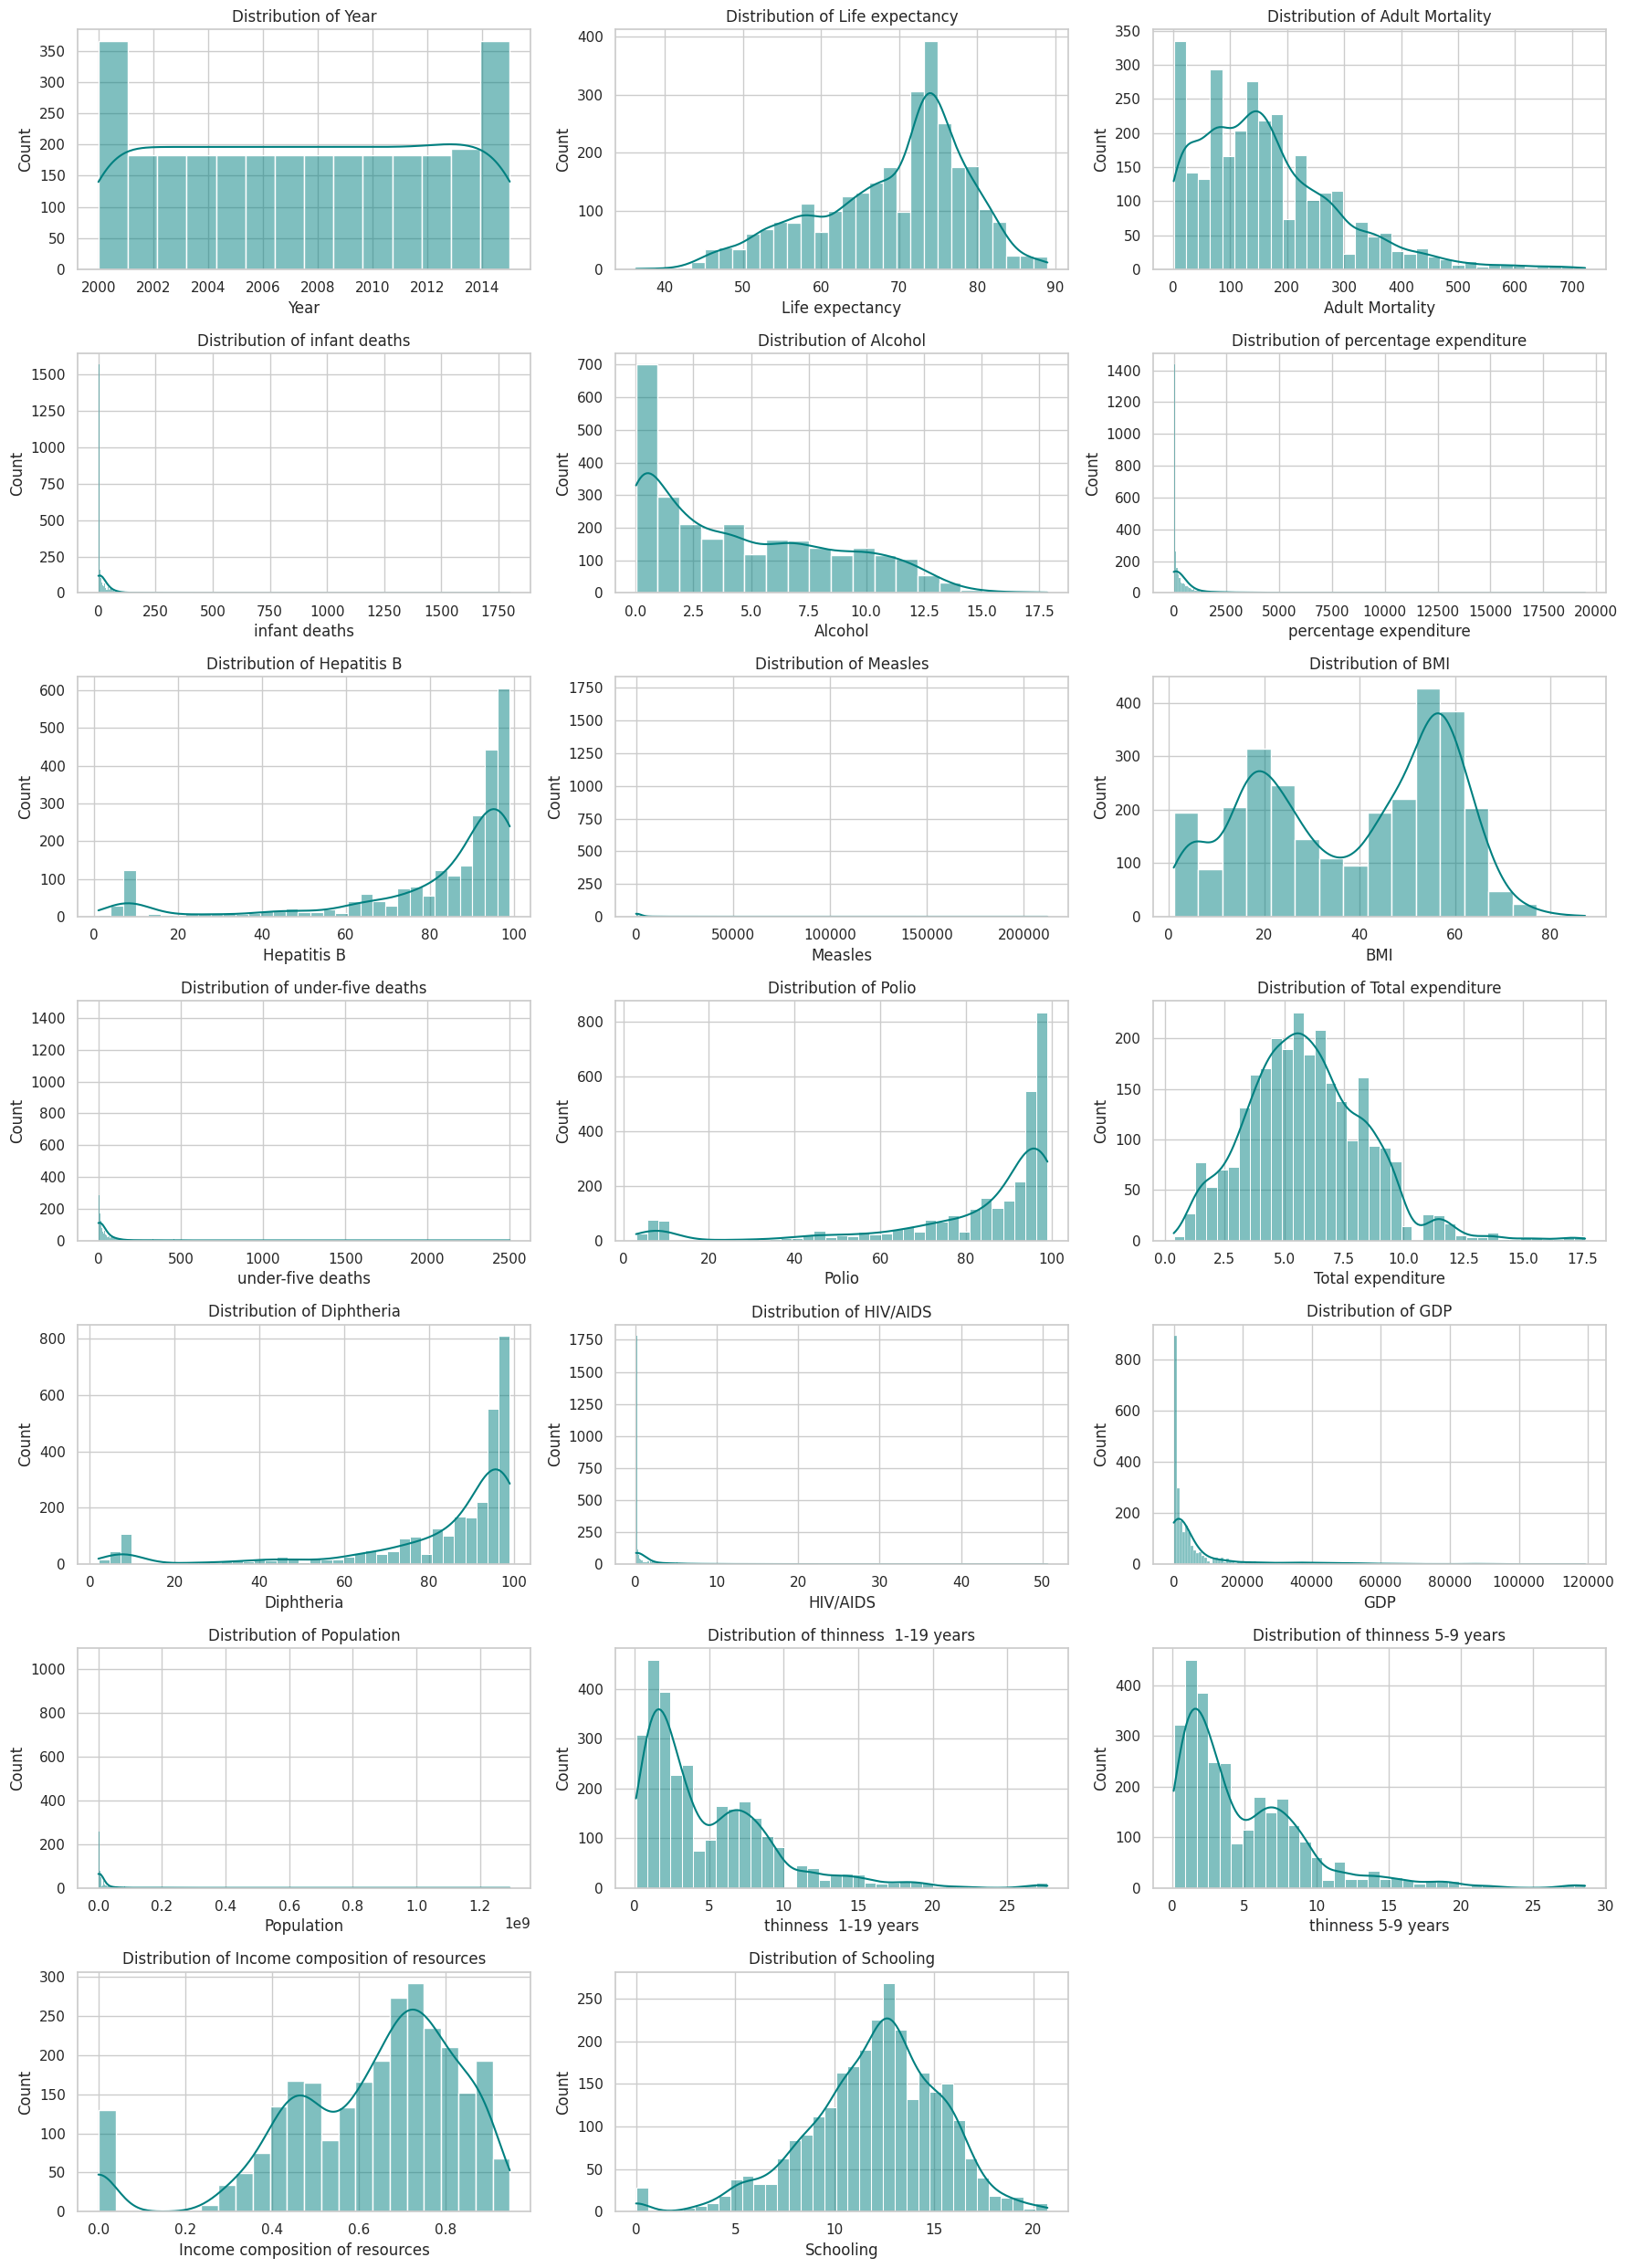

In [ ]:
# =========================================
# STEP 4: Exploratory Data Analysis (EDA)
# =========================================
print("\n--- Statistical Description ---")
display(dfc.describe())

# 1. Histograms for Numerical Distributions
num_cols = dfc.select_dtypes(include="number").columns
fig, axes = plt.subplots(len(num_cols) // 3 + 1, 3, figsize=(18, 25))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.histplot(data=dfc, x=col, kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f"Distribution of {col}")
# Hide extra subplots
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


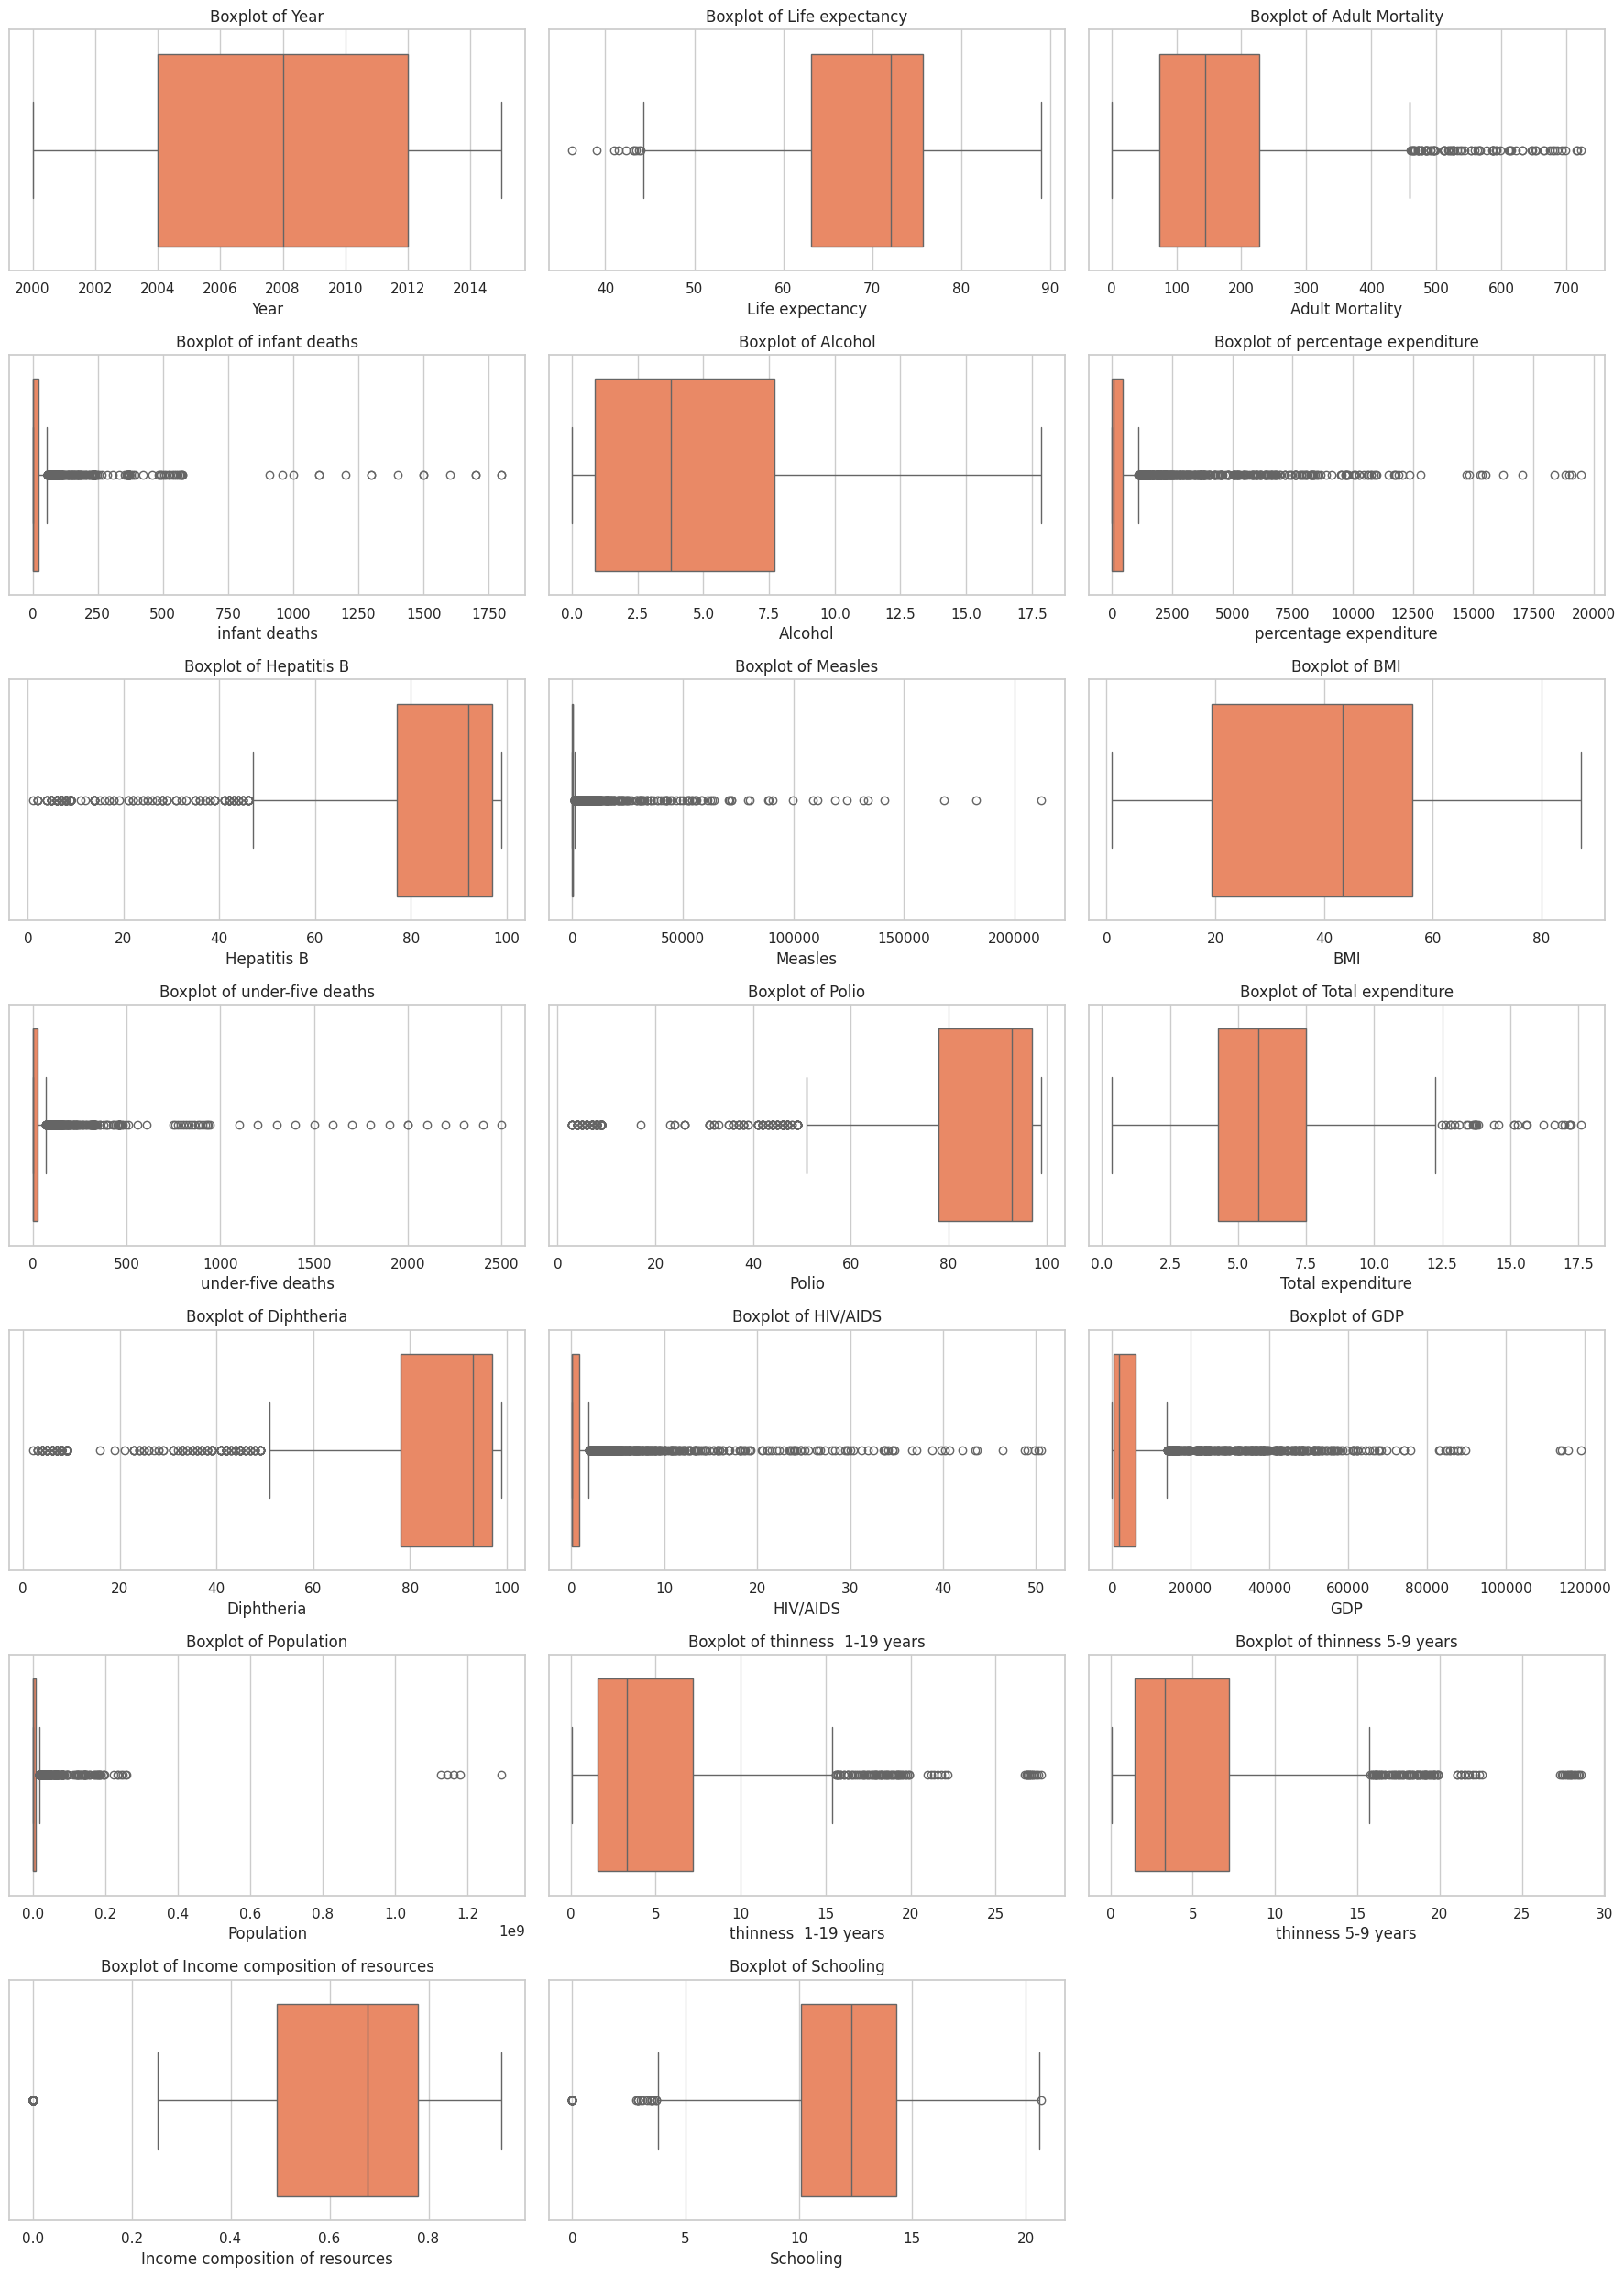

In [ ]:
# 2. Box Plots for Outlier Detection
fig, axes = plt.subplots(len(num_cols) // 3 + 1, 3, figsize=(18, 25))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.boxplot(data=dfc, x=col, ax=axes[idx], color='coral')
    axes[idx].set_title(f"Boxplot of {col}")

for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


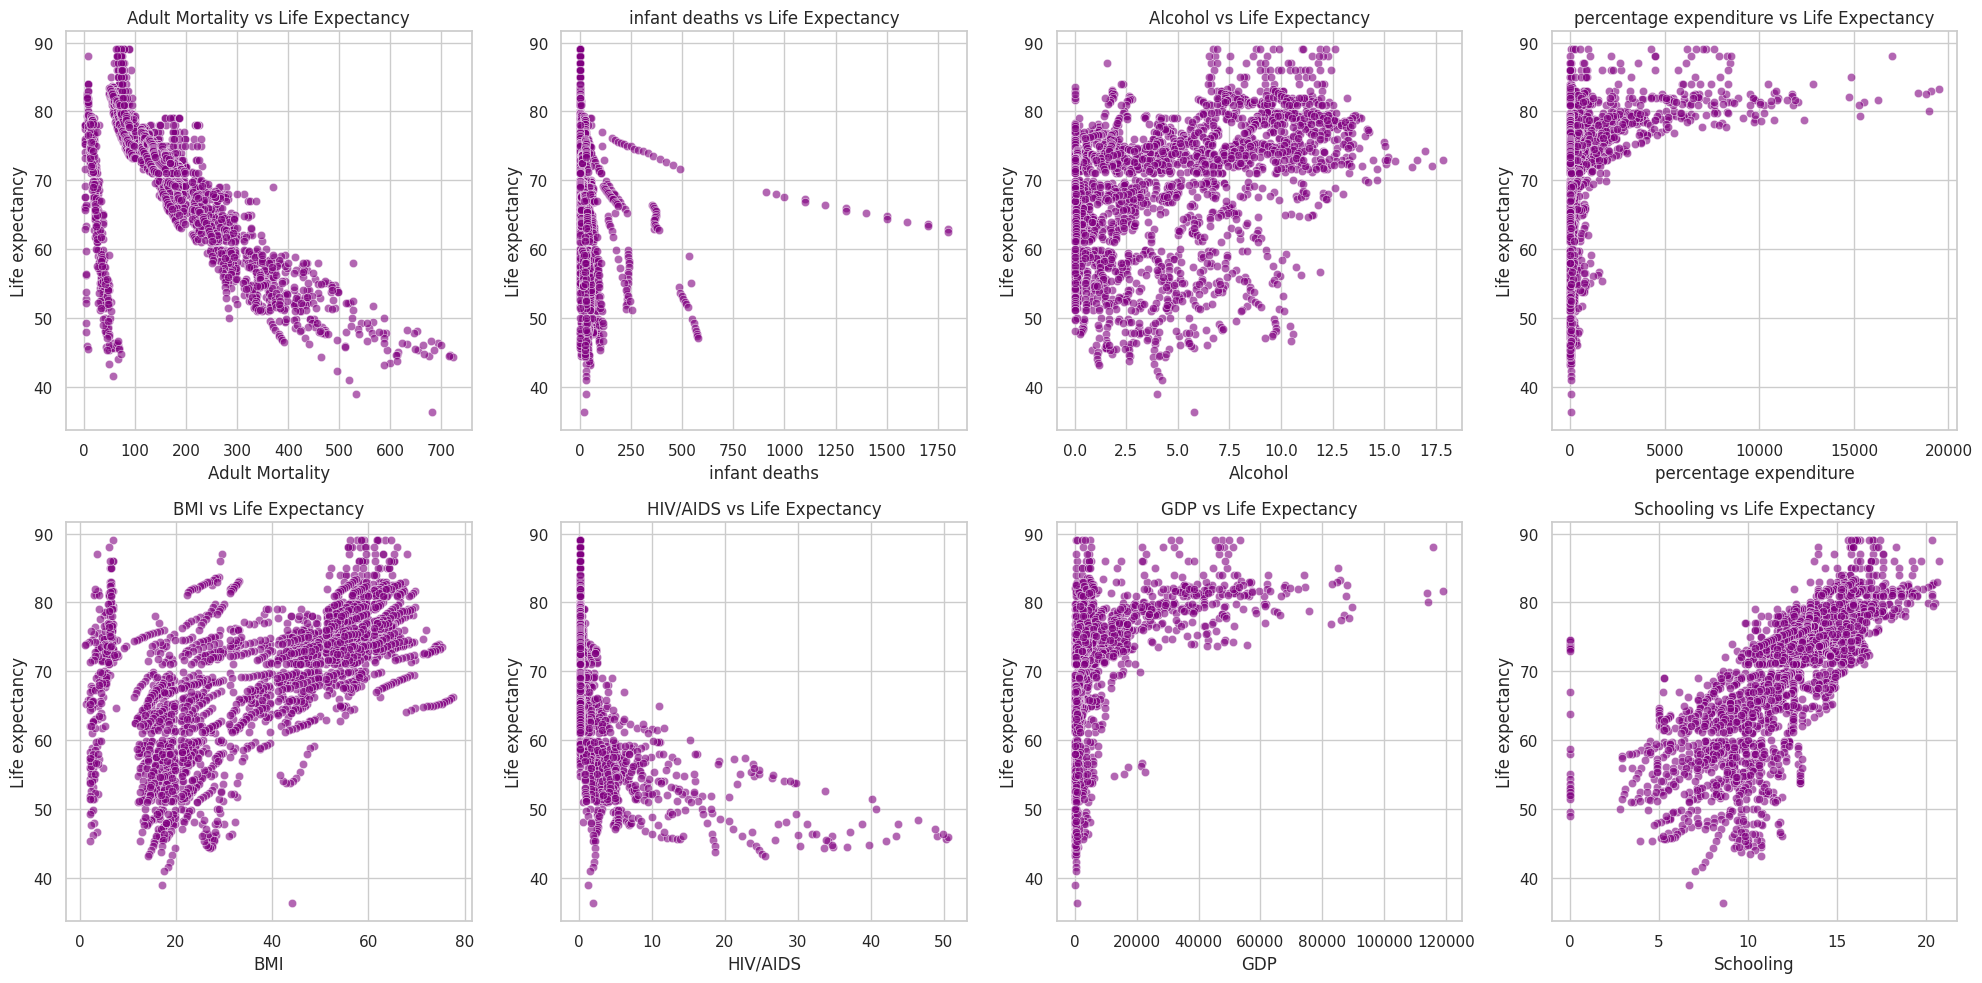

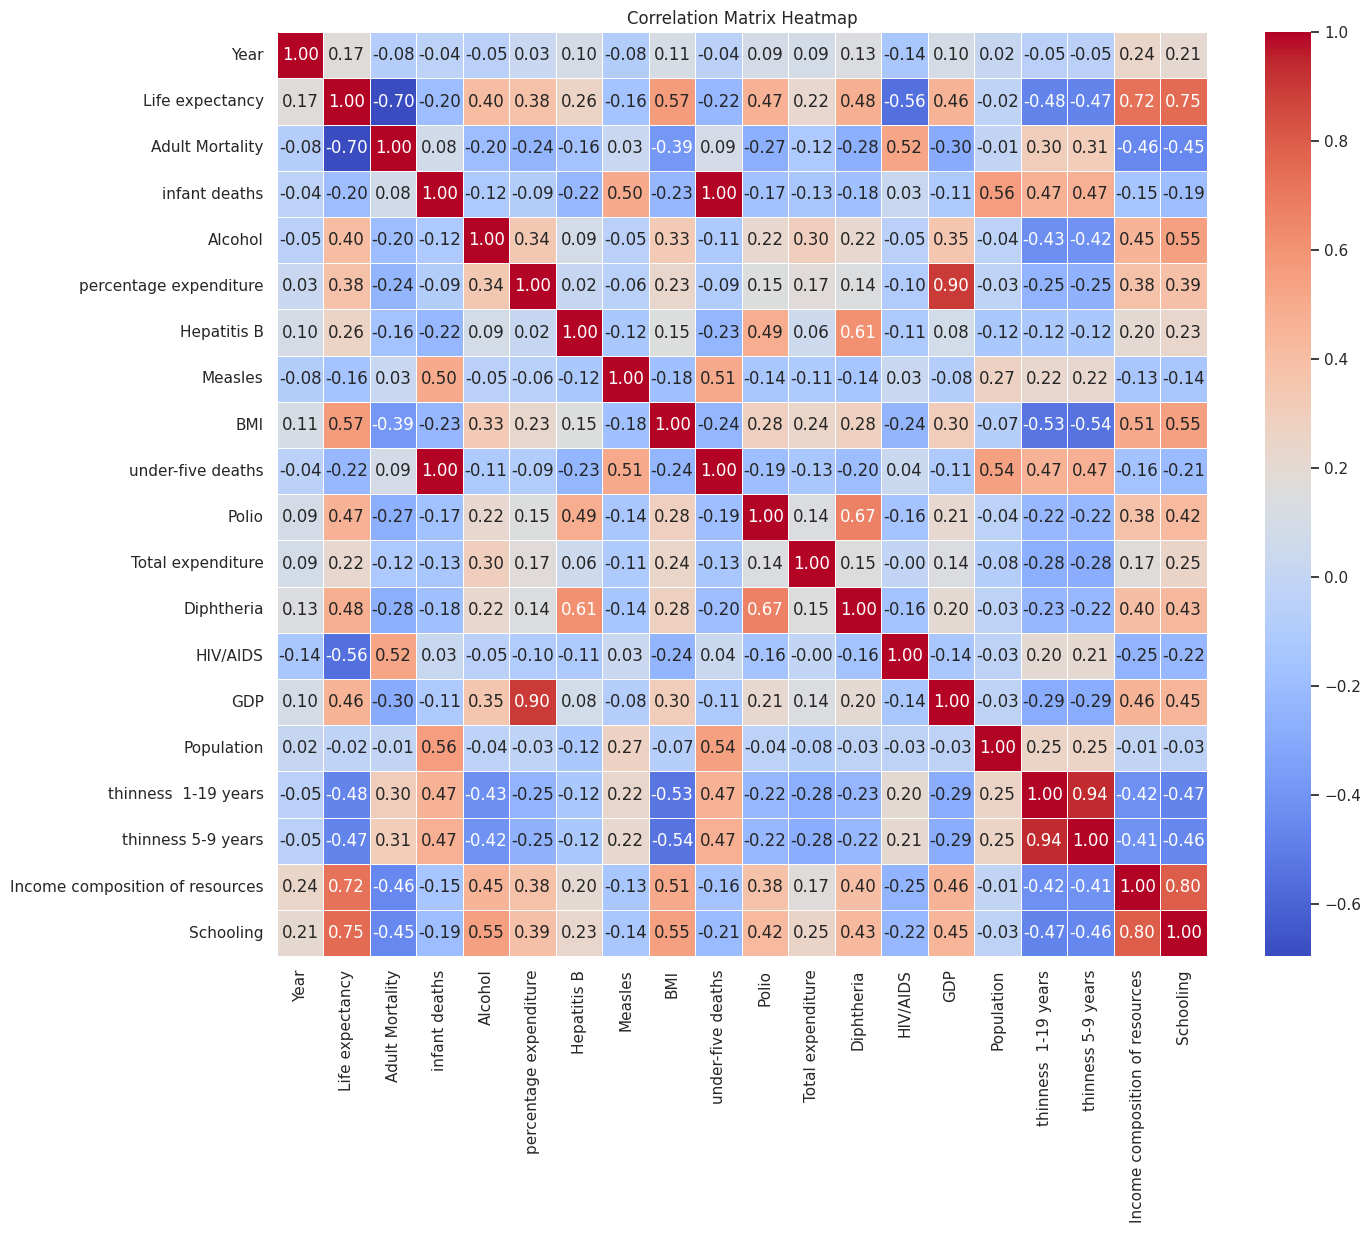

In [ ]:
# 3. Scatter Plots against Target Variable ('Life expectancy')
scatter_cols = ['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
                'BMI', 'HIV/AIDS', 'GDP', 'Schooling']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(scatter_cols):
    sns.scatterplot(data=dfc, x=col, y='Life expectancy', ax=axes[idx], alpha=0.6, color='purple')
    axes[idx].set_title(f"{col} vs Life Expectancy")

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(15, 12))
corr_matrix = dfc.select_dtypes(include="number").corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


In [ ]:
# =========================================
# STEP 5: Missing Value Treatments
# =========================================
# Drop rows where target variable 'Life expectancy' is missing
dfc = dfc.dropna(subset=['Life expectancy'])

# KNN Imputation for remaining numerical features
impute = KNNImputer(n_neighbors=5)
num_cols_impute = dfc.select_dtypes(include="number").columns
dfc[num_cols_impute] = impute.fit_transform(dfc[num_cols_impute])

print("\n--- Missing Values Count After Imputation ---")
print(dfc.isnull().sum().sum(), "missing values remaining.")



--- Missing Values Count After Imputation ---
0 missing values remaining.


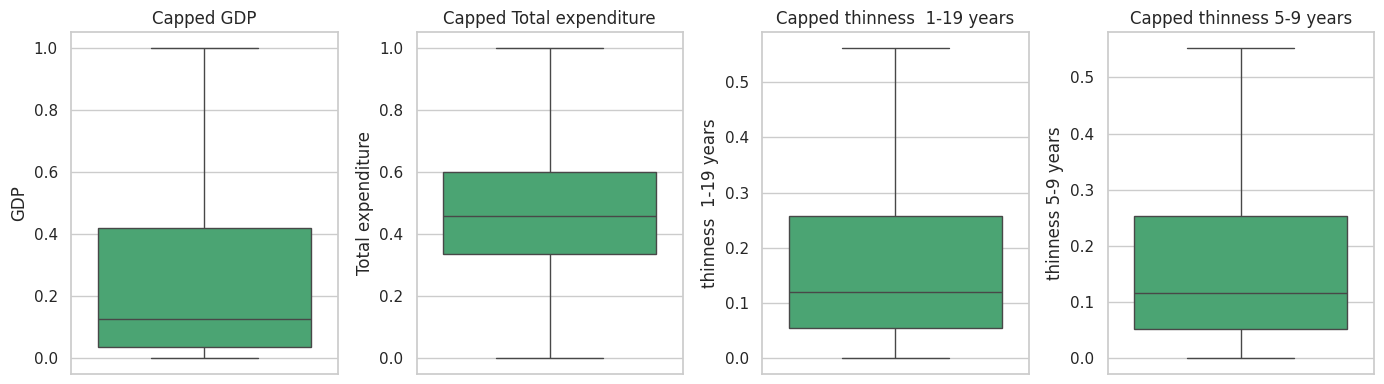

In [ ]:
# =========================================
# STEP 6: Outlier Treatment (IQR Capping)
# =========================================
def wisker(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5 * iqr
    uw = q3 + 1.5 * iqr
    return lw, uw

outlier_cols = ['GDP', 'Total expenditure', 'thinness  1-19 years', 'thinness 5-9 years']

for col in outlier_cols:
    lw, uw = wisker(dfc[col])
    dfc[col] = np.where(dfc[col] < lw, lw, dfc[col])
    dfc[col] = np.where(dfc[col] > uw, uw, dfc[col])

# Verify Capped Outliers with Boxplots
plt.figure(figsize=(14, 4))
for idx, col in enumerate(outlier_cols):
    plt.subplot(1, 4, idx + 1)
    sns.boxplot(data=dfc, y=col, color='mediumseagreen')
    plt.title(f"Capped {col}")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# STEP 7: Duplicates & Garbage Value Treatment
# =========================================
dfc = dfc.drop_duplicates()

# =========================================
# STEP 8: Normalization
# =========================================
scaler = MinMaxScaler()
numeric_cols = dfc.select_dtypes(include="number").columns
dfc[numeric_cols] = scaler.fit_transform(dfc[numeric_cols])

# =========================================
# STEP 9: Encoding
# =========================================
df_encoded = pd.get_dummies(data=dfc, columns=["Country", "Status"], drop_first=True)

print("\n--- Final Processed Dataset Preview ---")
print(f"Final Processed Dataset Shape: {df_encoded.shape}")
display(df_encoded.head())


--- Final Processed Dataset Preview ---
Final Processed Dataset Shape: (2928, 203)


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,...,Country_United States of America,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe,Status_Developing
0,1.000000,0.544592,0.362881,0.034444,0.0,0.003659,0.653061,0.005439,0.236292,0.0332,...,False,False,False,False,False,False,False,False,False,True
1,0.933333,0.447818,0.373961,0.035556,0.0,0.003774,0.622449,0.002319,0.229765,0.0344,...,False,False,False,False,False,False,False,False,False,True
2,0.866667,0.447818,0.369806,0.036667,0.0,0.003759,0.642857,0.002027,0.223238,0.0356,...,False,False,False,False,False,False,False,False,False,True
3,0.800000,0.440228,0.375346,0.038333,0.0,0.004014,0.673469,0.013135,0.216710,0.0372,...,False,False,False,False,False,False,False,False,False,True
4,0.733333,0.434535,0.379501,0.039444,0.0,0.000364,0.683673,0.014200,0.211488,0.0388,...,False,False,False,False,False,False,False,False,False,True


## 4. Discussion & Visual Output Interpretations

### 4.1 Exploratory Analysis Interpretations
* **Distribution Shapes (Histograms):** Several features such as `GDP`, `Population`, `Measles`, and `infant deaths` exhibit strong positive skewness, indicating that most developing countries cluster near lower value ranges while a few developed nations hold extreme high values.
* **Scatter Plots against `Life expectancy`:**
  * **Positive Linear Trends:** `Schooling` and `Income composition of resources` demonstrate strong positive correlations with `Life expectancy`. Higher education levels strongly map to longer life expectancies.
  * **Negative Linear Trends:** `Adult Mortality` and `HIV/AIDS` show sharp inverse relationships with `Life expectancy`.
* **Correlation Heatmap Analysis:** High multicollinearity exists between `infant deaths` and `under-five deaths` ($r > 0.95$), as well as between `thinness 1-19 years` and `thinness 5-9 years`.

### 4.2 Preprocessing Techniques Applied
1. **Sanity Check & Header Cleaning:** Column name whitespace was stripped (`str.strip()`), and target values missing life expectancy targets were safely removed.
2. **Outlier Capping:** IQR boundaries ($1.5 \times \text{IQR}$) successfully capped extreme values in `GDP`, `Total expenditure`, and `thinness` features without shrinking sample length.
3. **Min-Max Normalization & One-Hot Encoding:** Brought continuous values onto a uniform $[0, 1]$ scale and transformed high-cardinality categorical variables into binary dummy flags ($K-1$).

---

## 5. Conclusion
This laboratory session executed a full 9-step data preprocessing pipeline on the WHO Life Expectancy dataset. Visualizations confirmed data distributions, multicollinearity, and extreme outliers. Applying KNN imputation, IQR capping, Min-Max scaling, and dummy encoding yielded a fully clean, normalized numerical dataset optimized for training predictive Machine Learning models.